In [75]:
#importing Libraries and Dataset

import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import pickle
import pefile
import sklearn.ensemble as ek
from sklearn import tree, linear_model
from sklearn.feature_selection import SelectFromModel
import joblib
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn import preprocessing
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from mlxtend.plotting import plot_confusion_matrix
import seaborn as sns
from keras.metrics import Recall,Precision

import warnings
warnings.filterwarnings("ignore")





In [76]:
#Read the dataset
df = pd.read_csv("C:/Users/PRAVEEN/Desktop/oversampled_ransomware_dataset.csv")

In [77]:
from sklearn.metrics import f1_score
import sklearn.metrics


In [78]:
#Dataset Exploration
df

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,151298,14,51023,1328,443,6,4,151054,6,8,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,151298,14,51023,1328,443,6,4,349,2,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,148227,14,34259,1294,443,6,7,119,2,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,142970,14,55509,1247,443,6,8,37055,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,151270,14,44852,1328,443,6,9,178727,6,7,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
697881,145784,14,51160,2554,204,6,4323,20208221,3,1,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
697882,157606,13,41915,1497,443,6,4285,35,1,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
697883,39234,13,60413,480,80,6,8447,9369555,2,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
697884,44044,13,57280,2811,443,6,1588,34890,3,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [79]:
df.describe()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
count,697886.000000,697886.000000,697886.000000,697886.000000,697886.000000,697886.000000,697886.000000,6.978860e+05,697886.000000,697886.000000,...,6.978860e+05,6.978860e+05,6.978860e+05,6.978860e+05,6.978860e+05,6.978860e+05,6.978860e+05,6.978860e+05,6.978860e+05,697886.0
mean,108324.550108,141.765197,38692.425716,1343.287927,5901.263140,8.302899,26221.054447,1.066934e+07,7.147709,8.969611,...,-6.214242e+03,1.767971e+05,2.608594e+04,2.032817e+05,1.551973e+05,4.484194e+06,3.499997e+05,4.784478e+06,4.216638e+06,0.5
std,55524.269785,425.085350,18511.721432,1380.486184,15267.814115,4.550889,25686.111933,2.195103e+07,31.120553,78.176987,...,2.950782e+06,1.042415e+06,4.094666e+05,1.291433e+06,9.448695e+05,1.504147e+07,3.067461e+06,1.579305e+07,1.468544e+07,0.5
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,1.000000,0.000000,...,-1.395062e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,57285.000000,13.000000,34376.000000,21.000000,80.000000,6.000000,4909.000000,4.840700e+04,1.000000,0.000000,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,111010.500000,14.000000,43670.000000,1189.000000,443.000000,6.000000,10503.500000,5.102730e+05,2.000000,1.000000,...,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.5
75%,154095.000000,14.000000,52151.000000,2190.000000,443.000000,6.000000,48246.000000,1.050723e+07,5.000000,4.000000,...,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.0
max,203555.000000,2503.000000,65534.000000,5055.000000,65487.000000,17.000000,82539.000000,1.199997e+08,3632.000000,12820.000000,...,1.705249e+08,1.074960e+08,5.243613e+07,1.074960e+08,1.074960e+08,1.198864e+08,7.598323e+07,1.198864e+08,1.198864e+08,1.0


In [80]:
# Checking the size of dataframe
from sys import getsizeof
initial_size = getsizeof(df)/(1024.0**3)
print("Size of DataFrame: {} GB".format(initial_size))

Size of DataFrame: 0.4419708847999573 GB


In [81]:
df.isnull().sum()

Flow ID              0
 Source IP           0
 Source Port         0
 Destination IP      0
 Destination Port    0
                    ..
Idle Mean            0
 Idle Std            0
 Idle Max            0
 Idle Min            0
Label                0
Length: 85, dtype: int64

In [82]:
df.Label.value_counts() #1 means malware, 0 means Label

Label
0    348943
1    348943
Name: count, dtype: int64

In [83]:
# Converting labelled data in categories datatype
df.Label = df.Label.astype('category')
df.Label

0         0
1         0
2         0
3         0
4         0
         ..
697881    0
697882    0
697883    0
697884    0
697885    0
Name: Label, Length: 697886, dtype: category
Categories (2, int64): [0, 1]

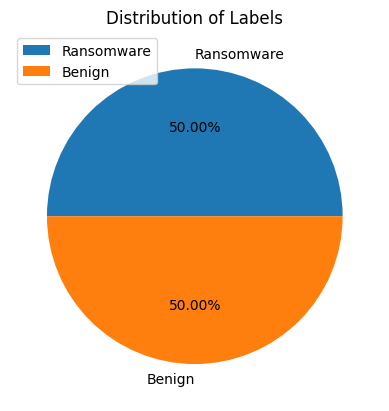

In [84]:
# Replace 'Label' with the actual column name for your labels
plt.pie(df['Label'].value_counts().values.tolist(), labels=['Ransomware', 'Benign'], autopct='%.2f%%')
plt.legend()
plt.title("Distribution of Labels")
plt.show()

In [85]:
#Column Analysis
df.shape[1]

85

In [86]:
df.columns

Index(['Flow ID', ' Source IP', ' Source Port', ' Destination IP',
       ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Pa

In [87]:
df.dtypes

Flow ID                 int64
 Source IP              int64
 Source Port            int64
 Destination IP         int64
 Destination Port       int64
                       ...   
Idle Mean             float64
 Idle Std             float64
 Idle Max             float64
 Idle Min             float64
Label                category
Length: 85, dtype: object

<Axes: >

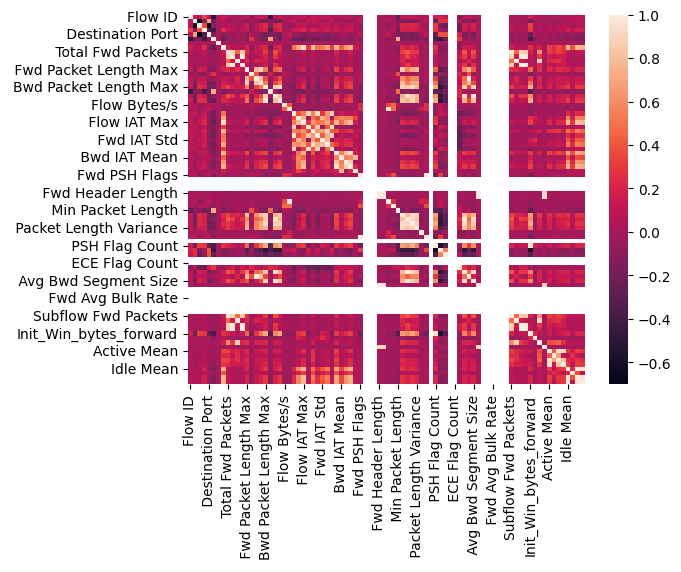

In [88]:
#EDA
# Select only the numeric columns from the DataFrame
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Now you can compute the correlation matrix
sns.heatmap(numeric_df.corr())




In [89]:
# Find columns with a single unique value (zero variance)
zero_variance_columns = df.columns[df.nunique() <= 1].tolist()
print("Zero-variance columns:", zero_variance_columns)


Zero-variance columns: [' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' RST Flag Count', ' CWE Flag Count', ' ECE Flag Count', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [90]:
# List of features to remove
columns_to_remove = [
    ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' RST Flag Count', ' CWE Flag Count', ' ECE Flag Count', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

# Drop these columns from the dataset
df = df.drop(columns=columns_to_remove, errors='ignore')

# Check the shape of the dataset after removal
print("Dataset shape after feature removal:", df.shape)


Dataset shape after feature removal: (697886, 73)


<Axes: >

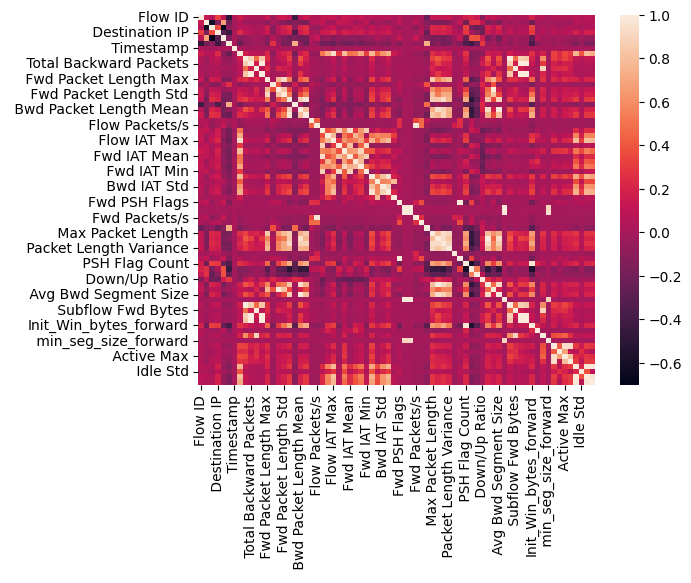

In [91]:
#EDA
# Select only the numeric columns from the DataFrame
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Now you can compute the correlation matrix
sns.heatmap(numeric_df.corr())




In [92]:
# Using VIF to remove highly correlated columns 
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Exclude non-numerical and target columns
cols_vif = df.select_dtypes(include=['number']).columns.tolist()
if 'Label' in cols_vif:  # Remove the target column if present
    cols_vif.remove('Label')

print("Columns considered for VIF calculation:", cols_vif)

# VIF dataframe
vif_data = pd.DataFrame()
vif_data["feature"] = cols_vif

# Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(df[cols_vif].values, i)
                   for i in range(len(cols_vif))]

print(vif_data)



Columns considered for VIF calculation: ['Flow ID', ' Source IP', ' Source Port', ' Destination IP', ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Cou

In [93]:
#Feature Extraction
def iv_woe(data, target, bins=10, show_woe=False):
    
    #Empty Dataframe
    newDF,woeDF = pd.DataFrame(), pd.DataFrame()
    
    #Extract Column Names
    cols = data.columns
    
    #Run WOE and IV on all the independent variables
    for ivars in cols[~cols.isin([target])]:
        if (data[ivars].dtype.kind in 'bifc') and (len(np.unique(data[ivars]))>10):
            binned_x = pd.qcut(data[ivars], bins,  duplicates='drop')
            d0 = pd.DataFrame({'x': binned_x, 'y': data[target]})
        else:
            d0 = pd.DataFrame({'x': data[ivars], 'y': data[target]})
        d = d0.groupby("x", as_index=False).agg({"y": ["count", "sum"]})
        d.columns = ['Cutoff', 'N', 'Events']
        d['% of Events'] = np.maximum(d['Events'], 0.5) / d['Events'].sum()
        d['Non-Events'] = d['N'] - d['Events']
        d['% of Non-Events'] = np.maximum(d['Non-Events'], 0.5) / d['Non-Events'].sum()
        d['WoE'] = np.log(d['% of Events']/d['% of Non-Events'])
        d['IV'] = d['WoE'] * (d['% of Events'] - d['% of Non-Events'])
        d.insert(loc=0, column='Variable', value=ivars)
        print("Information value of " + ivars + " is " + str(round(d['IV'].sum(),6)))
        temp =pd.DataFrame({"Variable" : [ivars], "IV" : [d['IV'].sum()]}, columns = ["Variable", "IV"])
        newDF=pd.concat([newDF,temp], axis=0)
        woeDF=pd.concat([woeDF,d], axis=0)

        #Show WOE Table
        if show_woe == True:
            print(d)
    return newDF, woeDF

In [94]:
df.Label = df.Label.astype('int64')


In [95]:
iv, woe = iv_woe(df, 'Label')



Information value of Flow ID is 0.111446
Information value of  Source IP is 0.401815
Information value of  Source Port is 0.0199
Information value of  Destination IP is 0.049647
Information value of  Destination Port is 0.006035
Information value of  Protocol is 0.000754
Information value of  Timestamp is 23.692577
Information value of  Flow Duration is 0.019548
Information value of  Total Fwd Packets is 0.011611
Information value of  Total Backward Packets is 0.007631
Information value of Total Length of Fwd Packets is 0.011658
Information value of  Total Length of Bwd Packets is 0.009381
Information value of  Fwd Packet Length Max is 0.002212
Information value of  Fwd Packet Length Min is 0.004957
Information value of  Fwd Packet Length Mean is 0.008336
Information value of  Fwd Packet Length Std is 0.002543
Information value of Bwd Packet Length Max is 0.004329
Information value of  Bwd Packet Length Min is 0.001022
Information value of  Bwd Packet Length Mean is 0.011428
Informatio

In [96]:
iv.sort_values(by = 'IV', ascending=False)


,Variable,IV
0,Timestamp,23.692577
0,min_seg_size_forward,0.748056
0,Source IP,0.401815
0,Bwd Header Length,0.248201
0,Flow ID,0.111446
...,...,...
0,Bwd Packet Length Min,0.001022
0,Protocol,0.000754
0,URG Flag Count,0.000165
0,Active Std,0.000000


In [97]:
features = iv.sort_values(by = 'IV', ascending=False)['Variable'][:85].values.tolist()

In [98]:
features

[' Timestamp',
 ' min_seg_size_forward',
 ' Source IP',
 ' Bwd Header Length',
 'Flow ID',
 ' Destination IP',
 ' Flow IAT Min',
 ' Init_Win_bytes_backward',
 'Init_Win_bytes_forward',
 ' Flow IAT Max',
 ' Source Port',
 ' Flow Duration',
 ' Subflow Fwd Bytes',
 ' Average Packet Size',
 ' Bwd IAT Min',
 ' Fwd Header Length',
 ' Fwd Header Length.1',
 ' Fwd IAT Max',
 'Fwd IAT Total',
 'Total Length of Fwd Packets',
 'Subflow Fwd Packets',
 ' Total Fwd Packets',
 ' Fwd IAT Std',
 ' Bwd Packet Length Mean',
 ' Avg Bwd Segment Size',
 'Fwd Packets/s',
 ' Bwd Packet Length Std',
 ' Flow Packets/s',
 ' Subflow Bwd Bytes',
 ' Total Length of Bwd Packets',
 ' Fwd IAT Mean',
 ' Avg Fwd Segment Size',
 ' Fwd Packet Length Mean',
 ' Max Packet Length',
 ' Flow IAT Mean',
 ' Packet Length Mean',
 ' Subflow Bwd Packets',
 ' Total Backward Packets',
 ' Bwd Packets/s',
 ' Fwd IAT Min',
 ' Destination Port',
 ' Packet Length Variance',
 ' Packet Length Std',
 ' act_data_pkt_fwd',
 ' Down/Up Ratio',
 

In [99]:
df.columns = df.columns.str.strip()


In [100]:
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])


Series([], dtype: int64)


In [101]:
print(df.columns.tolist())


['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio', 'Av

In [102]:
# Normalize the column names in the DataFrame
df.columns = df.columns.str.strip().str.lower().str.replace('_', ' ').str.replace('.', '').str.replace('-', ' ')

# Normalize the feature names in the `features` list
normalized_features = [feature.strip().lower().replace('_', ' ').replace('.', '').replace('-', ' ') for feature in features]


In [103]:
for feature in normalized_features:
    matching_columns = [col for col in df.columns if feature in col]
    if matching_columns:
        print(f"Matching columns for '{feature}': {matching_columns}")
    else:
        print(f"No matches found for feature: {feature}")


Matching columns for 'timestamp': ['timestamp']
Matching columns for 'min seg size forward': ['min seg size forward']
Matching columns for 'source ip': ['source ip']
Matching columns for 'bwd header length': ['bwd header length']
Matching columns for 'flow id': ['flow id']
Matching columns for 'destination ip': ['destination ip']
Matching columns for 'flow iat min': ['flow iat min']
Matching columns for 'init win bytes backward': ['init win bytes backward']
Matching columns for 'init win bytes forward': ['init win bytes forward']
Matching columns for 'flow iat max': ['flow iat max']
Matching columns for 'source port': ['source port']
Matching columns for 'flow duration': ['flow duration']
Matching columns for 'subflow fwd bytes': ['subflow fwd bytes']
Matching columns for 'average packet size': ['average packet size']
Matching columns for 'bwd iat min': ['bwd iat min']
Matching columns for 'fwd header length': ['fwd header length', 'fwd header length1']
Matching columns for 'fwd header

In [104]:
for feature in normalized_features:
    print(f"Feature: '{feature}'")
    print(f"Closest matches: {[col for col in df.columns if feature[:5] in col[:5]]}")  # Check for partial matches
    print('---')


Feature: 'timestamp'
Closest matches: ['timestamp']
---
Feature: 'min seg size forward'
Closest matches: ['min seg size forward']
---
Feature: 'source ip'
Closest matches: ['source ip', 'source port']
---
Feature: 'bwd header length'
Closest matches: ['bwd header length']
---
Feature: 'flow id'
Closest matches: ['flow id', 'flow duration', 'flow bytes/s', 'flow packets/s', 'flow iat mean', 'flow iat std', 'flow iat max', 'flow iat min']
---
Feature: 'destination ip'
Closest matches: ['destination ip', 'destination port']
---
Feature: 'flow iat min'
Closest matches: ['flow id', 'flow duration', 'flow bytes/s', 'flow packets/s', 'flow iat mean', 'flow iat std', 'flow iat max', 'flow iat min']
---
Feature: 'init win bytes backward'
Closest matches: ['init win bytes forward', 'init win bytes backward']
---
Feature: 'init win bytes forward'
Closest matches: ['init win bytes forward', 'init win bytes backward']
---
Feature: 'flow iat max'
Closest matches: ['flow id', 'flow duration', 'flow b

In [105]:
# Create a dictionary to map mismatched features to the correct column names
manual_mapping = {
    'init win bytes backward': 'init_win_bytes_backward',  # Example mapping
    'flow iat min': 'flow iat min',
    # Add more mappings as necessary
}

# Apply the manual mapping for unmatched features
final_features = [manual_mapping.get(feature, feature) for feature in normalized_features]


In [106]:
for feature in final_features:
    matching_columns = [col for col in df.columns if feature in col]
    if matching_columns:
        print(f"Matching columns for '{feature}': {matching_columns}")
    else:
        print(f"No matches found for feature: {feature}")


Matching columns for 'timestamp': ['timestamp']
Matching columns for 'min seg size forward': ['min seg size forward']
Matching columns for 'source ip': ['source ip']
Matching columns for 'bwd header length': ['bwd header length']
Matching columns for 'flow id': ['flow id']
Matching columns for 'destination ip': ['destination ip']
Matching columns for 'flow iat min': ['flow iat min']
No matches found for feature: init_win_bytes_backward
Matching columns for 'init win bytes forward': ['init win bytes forward']
Matching columns for 'flow iat max': ['flow iat max']
Matching columns for 'source port': ['source port']
Matching columns for 'flow duration': ['flow duration']
Matching columns for 'subflow fwd bytes': ['subflow fwd bytes']
Matching columns for 'average packet size': ['average packet size']
Matching columns for 'bwd iat min': ['bwd iat min']
Matching columns for 'fwd header length': ['fwd header length', 'fwd header length1']
Matching columns for 'fwd header length1': ['fwd heade

In [107]:
print(df.columns.tolist())


['flow id', 'source ip', 'source port', 'destination ip', 'destination port', 'protocol', 'timestamp', 'flow duration', 'total fwd packets', 'total backward packets', 'total length of fwd packets', 'total length of bwd packets', 'fwd packet length max', 'fwd packet length min', 'fwd packet length mean', 'fwd packet length std', 'bwd packet length max', 'bwd packet length min', 'bwd packet length mean', 'bwd packet length std', 'flow bytes/s', 'flow packets/s', 'flow iat mean', 'flow iat std', 'flow iat max', 'flow iat min', 'fwd iat total', 'fwd iat mean', 'fwd iat std', 'fwd iat max', 'fwd iat min', 'bwd iat total', 'bwd iat mean', 'bwd iat std', 'bwd iat max', 'bwd iat min', 'fwd psh flags', 'fwd header length', 'bwd header length', 'fwd packets/s', 'bwd packets/s', 'min packet length', 'max packet length', 'packet length mean', 'packet length std', 'packet length variance', 'fin flag count', 'syn flag count', 'psh flag count', 'ack flag count', 'urg flag count', 'down/up ratio', 'av

In [108]:
# Ensure all features are numeric
X = df.drop('label',axis=1)
y = df['label']


In [109]:
# Encode categorical features using LabelEncoder
categorical_columns = ['flow id', 'source ip', 'destination ip']  
encoder = LabelEncoder()

for col in categorical_columns:
    X[col] = encoder.fit_transform(X[col])

In [110]:
#Split dataset
randomseed = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=randomseed)

In [111]:
print(X_test.shape[0] + X_train.shape[0])
print('Training labels shape:', y_train.shape)
print('Test labels shape:', y_test.shape)
print('Training features shape:', X_train.shape)
print('Test features shape:', X_test.shape)

697886
Training labels shape: (558308,)
Test labels shape: (139578,)
Training features shape: (558308, 72)
Test features shape: (139578, 72)


In [112]:
# Ensure labels are numeric
y_train = np.array(y_train).astype(int)
y_test = np.array(y_test).astype(int)


In [113]:
# Reshape labels for binary classification
Y_train = np.expand_dims(y_train, axis=1)  # Shape should be (None, 1)
Y_test = np.expand_dims(y_test, axis=1)

In [114]:
from sklearn.preprocessing import StandardScaler

# Convert DataFrame to numpy arrays and standardize
scaler = StandardScaler()

# Flatten the features for scaling (2D format)
X_train_scaled = scaler.fit_transform(X_train.values.reshape(X_train.shape[0], -1))  # Flatten for scaling
X_test_scaled = scaler.transform(X_test.values.reshape(X_test.shape[0], -1))


In [115]:

print('Scaled Training features shape:', X_train_scaled.shape)
print('Scaled Test features shape:', X_test_scaled.shape)


Scaled Training features shape: (558308, 72)
Scaled Test features shape: (139578, 72)


In [116]:
# Compute class weights to handle class imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))


In [129]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Define the XGBoost classifier
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=8,
    learning_rate=0.001,
    n_estimators=100,
    subsample=0.5,
    colsample_bytree=0.5,
    reg_lambda=1,
    reg_alpha=0.1,
    scale_pos_weight=class_weight_dict[1] / class_weight_dict[0],
    eval_metric=['logloss', 'error', 'aucpr']
)

# Train the model on training and test sets
st = time.time()
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],  # <-- Added training set here
    verbose=True
)
print(f'Train time: {time.time() - st:.2f} sec.')

# Make predictions
y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Get evaluation results
evals_result = xgb_model.evals_result()

# Extract train and test metrics
train_error = evals_result['validation_0']['error']
test_error = evals_result['validation_1']['error']
train_logloss = evals_result['validation_0']['logloss']
test_logloss = evals_result['validation_1']['logloss']
train_aucpr = evals_result['validation_0']['aucpr']
test_aucpr = evals_result['validation_1']['aucpr']




[0]	validation_0-logloss:0.69215	validation_0-error:0.00019	validation_0-aucpr:1.00000	validation_1-logloss:0.69215	validation_1-error:0.00019	validation_1-aucpr:1.00000
[1]	validation_0-logloss:0.69115	validation_0-error:0.00019	validation_0-aucpr:1.00000	validation_1-logloss:0.69115	validation_1-error:0.00015	validation_1-aucpr:1.00000
[2]	validation_0-logloss:0.69088	validation_0-error:0.00018	validation_0-aucpr:0.99996	validation_1-logloss:0.69088	validation_1-error:0.00016	validation_1-aucpr:0.99992
[3]	validation_0-logloss:0.69054	validation_0-error:0.00017	validation_0-aucpr:0.99997	validation_1-logloss:0.69054	validation_1-error:0.00016	validation_1-aucpr:0.99992
[4]	validation_0-logloss:0.68954	validation_0-error:0.00017	validation_0-aucpr:0.99998	validation_1-logloss:0.68954	validation_1-error:0.00016	validation_1-aucpr:0.99993
[5]	validation_0-logloss:0.68855	validation_0-error:0.00017	validation_0-aucpr:0.99999	validation_1-logloss:0.68855	validation_1-error:0.00016	validat

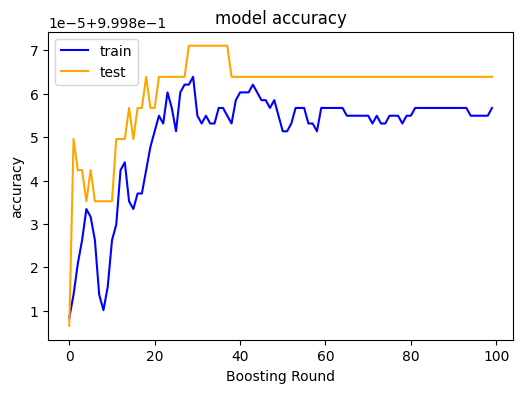

In [130]:
evals_result = xgb_model.evals_result()

# 'validation_0' is train, 'validation_0' is test
train_error = evals_result['validation_0']['error']
eval_error = evals_result['validation_1']['error']

import matplotlib.pyplot as plt
#Accuracy, Loss, Precision, Recall, 
plt.figure(figsize=(6, 4))
plt.plot(train_accuracy, label='Train Accuracy', color='blue')
plt.plot(eval_accuracy, label='Test Accuracy', color='orange')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('Boosting Round')
plt.legend(['train', 'test'], loc='upper left')
plt.show()



In [131]:
# Time
import time
st = time.time()
xgb_model.fit(X_train_scaled,y_train)
print('Train time: ', time.time()-st, 'sec.')


Train time:  13.175468921661377 sec.


In [132]:
#Testing performance of model
st = time.time()
y_pred = xgb_model.predict(X_test_scaled)
print('Test time: ', time.time()-st, 'sec.')


Test time:  0.1466515064239502 sec.


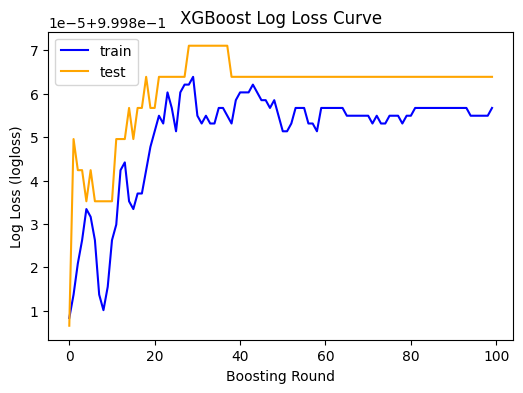

In [158]:
# Retrieve training and validation metrics for multi-class
results = xgb_model.evals_result()
# 'validation_0' is train, 'validation_0' is test
train_logloss = evals_result['validation_0']['logloss']
test_logloss = evals_result['validation_1']['logloss']

import matplotlib.pyplot as plt
#Accuracy, Loss, Precision, Recall, 
plt.figure(figsize=(6, 4))
plt.plot(train_accuracy, label='Train Accuracy', color='blue')
plt.plot(eval_accuracy, label='Test Accuracy', color='orange')
plt.title('XGBoost Log Loss Curve')
plt.ylabel('Log Loss (logloss)')
plt.xlabel('Boosting Round')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

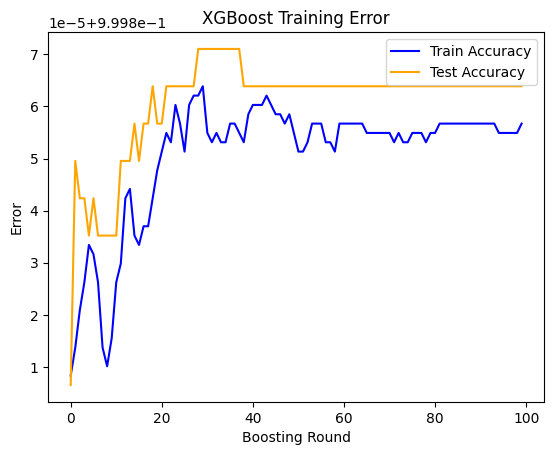

In [166]:

# Plot Validation Error
plt.plot(train_accuracy, label='Train Accuracy', color='blue')
plt.plot(eval_accuracy, label='Test Accuracy', color='orange')
eval_error = evals_result['validation_1']['error']
plt.title('XGBoost Training Error')
plt.xlabel('Boosting Round')
plt.ylabel('Error')
plt.legend()
plt.show()

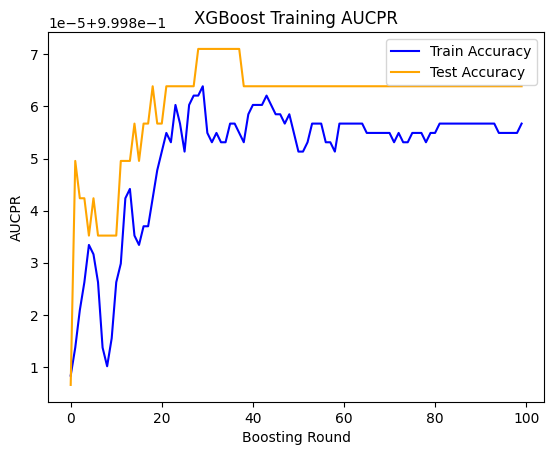

In [167]:
# Plot Validation AUCPR
plt.plot(train_accuracy, label='Train Accuracy', color='blue')
plt.plot(eval_accuracy, label='Test Accuracy', color='orange')
plt.title('XGBoost Training AUCPR')
plt.xlabel('Boosting Round')
plt.ylabel('AUCPR')
plt.legend()
plt.show()

In [161]:
from sklearn.metrics import roc_auc_score
# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)  # ROC AUC Score
aucpr = average_precision_score(y_test, y_pred_proba)  # AUCPR Score

# Print Metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"AUCPR Score: {aucpr:.4f}")

Accuracy: 0.9999
Precision: 0.9997
Recall: 1.0000
F1 Score: 0.9999
ROC AUC Score: 1.0000
AUCPR Score: 1.0000


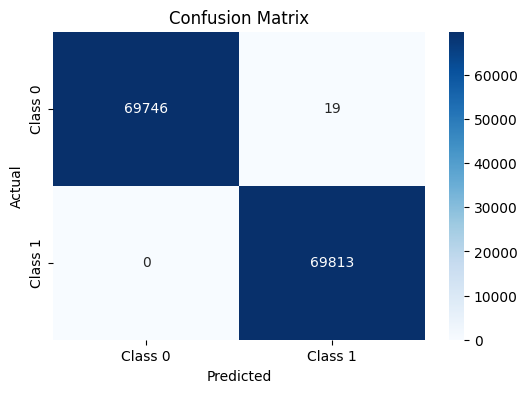

In [162]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions (convert probabilities to binary class)
y_pred_classes = (xgb_model.predict(X_test_scaled) > 0.5).astype(int)
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

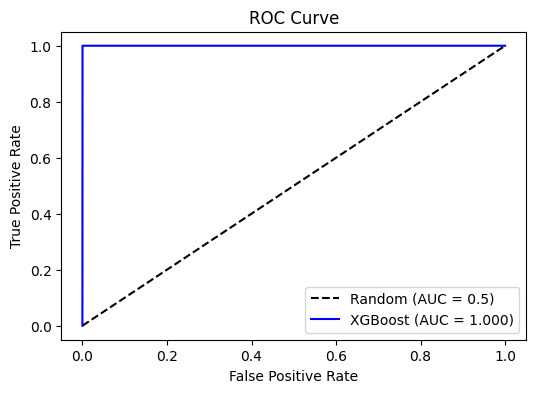

In [163]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_pred_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]  

# Compute ROC curve and AUC score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 4))
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.3f})', color='blue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

In [164]:
import numpy as np

# Define the confusion matrix
# Format: [[TP, FN], [FP, TN]]
confusion_matrix = np.array([[69746, 19], [0, 69813]])

# Extract values from the confusion matrix
TP = confusion_matrix[0, 0]
FN = confusion_matrix[0, 1]
FP = confusion_matrix[1, 0]
TN = confusion_matrix[1, 1]

# Calculate accuracy, precision, and recall, f1_score
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0


# Print the results
print(f"Accuracy: {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1 Score: {f1_score:.6f}")


Accuracy: 0.999864
Precision: 1.000000
Recall: 0.999728
F1 Score: 0.999864


In [165]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Predict probabilities for training data
yhat_probs_train = xgb_model.predict_proba(X_train_scaled)[:, 1]  # Get probabilities for the positive class

# Convert predicted probabilities into classes (0 or 1)
threshold = 0.5
yhat_classes_train = np.where(yhat_probs_train > threshold, 1, 0)
# Evaluate metrics on training data
accuracy_train = accuracy_score(y_train, yhat_classes_train)
print(f'Training Accuracy: {accuracy_train:.6f}')

precision_train = precision_score(y_train, yhat_classes_train, average='binary')  # For binary classification
print(f'Training Precision: {precision_train:.6f}')

recall_train = recall_score(y_train, yhat_classes_train, average='binary')  # For binary classification
print(f'Training Recall: {recall_train:.6f}')

f1_train = f1_score(y_train, yhat_classes_train, average='binary')  # For binary classification
print(f'Training F1 score: {f1_train:.6f}')

Training Accuracy: 0.999857
Training Precision: 0.999713
Training Recall: 1.000000
Training F1 score: 0.999857
